# Week 5：scikit-learn 逻辑回归与模型评估

目标：把数据预处理器与逻辑回归组合成一个 Pipeline，在训练集上拟合，在验证集上评估。

你前面手写过的核心仍然存在：

$$z=Xw+b$$

$$p=\sigma(z)$$

$$\mathrm{BCE}=-\frac1n\sum_i[y_i\log p_i+(1-y_i)\log(1-p_i)]$$

In [1]:
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

## 1. 读取与划分数据

这里保留测试集不动。当前只使用训练集拟合模型、验证集观察效果。

In [2]:
dataset = load_breast_cancer(as_frame=True)
df = dataset.frame.copy()

X = df.drop(columns='target')
y = df['target']

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

print('train:', X_train.shape)
print('validation:', X_val.shape)
print('test:', X_test.shape)

train: (341, 30)
validation: (114, 30)
test: (114, 30)


## 2. 建立模型 Pipeline

Pipeline 保证每次调用 `fit(X_train, y_train)` 时：先在训练集上学习标准化统计量，再训练逻辑回归。之后对验证集 `predict` 时，标准化器只会调用 `transform`。

`max_iter=1000` 的含义是：最多迭代 1000 次，让优化器有足够机会收敛；它不是模型复杂度。

In [3]:
model = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42)),
])

model.fit(X_train, y_train)

# predict 给出类别；predict_proba 给出每一类的概率。
y_val_pred = model.predict(X_val)
y_val_prob = model.predict_proba(X_val)[:, 1]

print('first 5 predicted probabilities:', y_val_prob[:5].round(3))
print('first 5 predicted classes:', y_val_pred[:5])

first 5 predicted probabilities: [0.992 0.    0.    1.    0.979]
first 5 predicted classes: [1 0 0 1 1]


## 3. 验证集指标

本节先计算 Accuracy、Precision、Recall、F1 和混淆矩阵。下一节会用这些数判断模型优缺点，而不是只看 Accuracy。

In [4]:
metrics = {
    'accuracy': accuracy_score(y_val, y_val_pred),
    'precision': precision_score(y_val, y_val_pred),
    'recall': recall_score(y_val, y_val_pred),
    'f1': f1_score(y_val, y_val_pred),
}

print(pd.Series(metrics).round(3))
print('\nconfusion matrix [rows=true, columns=predicted]:\n', confusion_matrix(y_val, y_val_pred))

accuracy     0.991
precision    0.986
recall       1.000
f1           0.993
dtype: float64

confusion matrix [rows=true, columns=predicted]:
 [[42  1]
 [ 0 71]]


## 今日检查点

运行后回答：

1. `model.fit(X_train, y_train)` 中，哪一步学习标准化参数，哪一步学习分类模型参数？
2. `predict` 与 `predict_proba` 的输出有什么区别？
3. 为什么当前不能使用 `X_test` 和 `y_test` 来报告模型效果？

## 4. 解读混淆矩阵与指标

本次验证集的混淆矩阵为：

$$\begin{bmatrix}42 & 1\\0 & 71\end{bmatrix}$$

行表示真实类别，列表示预测类别，因此：

- $TN=42$：真实为 0，预测也为 0；
- $FP=1$：真实为 0，却预测为 1，称为误报；
- $FN=0$：真实为 1，却预测为 0，称为漏报；
- $TP=71$：真实为 1，预测也为 1。

$$\mathrm{Accuracy}=\frac{TP+TN}{TP+TN+FP+FN}=\frac{113}{114}\approx0.991$$

$$\mathrm{Precision}=\frac{TP}{TP+FP}=\frac{71}{72}\approx0.986$$

$$\mathrm{Recall}=\frac{TP}{TP+FN}=\frac{71}{71}=1.0$$

$$F1=2\cdot\frac{\mathrm{Precision}\cdot\mathrm{Recall}}{\mathrm{Precision}+\mathrm{Recall}}\approx0.993$$

若类别 1 表示需要干预的高风险学生，那么 Recall 衡量是否漏掉真正需要帮助的人，Precision 衡量预警名单是否可靠。具体更重视哪个指标，取决于漏报和误报的实际成本。

## 5. 分类阈值（threshold）的取舍

`predict` 默认等价于使用阈值 $0.5$：

$$\hat y=\mathbb{1}(p\ge t)$$

降低阈值 $t$ 会让更多样本被预测为正类：Recall 通常提高，但误报增加、Precision 通常下降。提高阈值则相反。

In [5]:
import numpy as np

thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]
rows = []

for threshold in thresholds:
    y_pred_at_threshold = (y_val_prob >= threshold).astype(int)
    rows.append({
        'threshold': threshold,
        'precision': precision_score(y_val, y_pred_at_threshold, zero_division=0),
        'recall': recall_score(y_val, y_pred_at_threshold, zero_division=0),
        'f1': f1_score(y_val, y_pred_at_threshold, zero_division=0),
        'predicted_positive': int(y_pred_at_threshold.sum()),
    })

threshold_results = pd.DataFrame(rows)
print(threshold_results.round(3))

# 查看一个较低阈值下的混淆矩阵。
low_threshold = 0.3
y_pred_low = (y_val_prob >= low_threshold).astype(int)
print(f'\nconfusion matrix at threshold={low_threshold}:')
print(confusion_matrix(y_val, y_pred_low))

   threshold  precision  recall     f1  predicted_positive
0        0.1      0.899   1.000  0.947                  79
1        0.3      0.959   1.000  0.979                  74
2        0.5      0.986   1.000  0.993                  72
3        0.7      0.986   0.972  0.979                  70
4        0.9      1.000   0.901  0.948                  64

confusion matrix at threshold=0.3:
[[40  3]
 [ 0 71]]


### 检查点

观察输出后回答：把阈值从 0.5 降到 0.3，预测为正类的人数通常会如何变化？为什么这可能提高 Recall、降低 Precision？

## 6. ROC 曲线与 AUC

ROC 曲线把所有可能阈值对应的点连起来：

$$\mathrm{TPR}=\frac{TP}{TP+FN}=\mathrm{Recall}$$

$$\mathrm{FPR}=\frac{FP}{FP+TN}$$

横轴是 FPR，纵轴是 TPR。曲线越贴近左上角，模型越好。AUC 是曲线下面积：$0.5$ 接近随机猜测，$1.0$ 表示排序完美。

validation AUC = 0.998


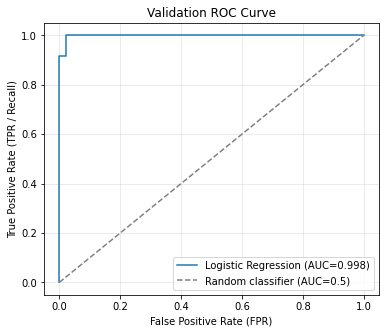

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_val, y_val_prob)
auc = roc_auc_score(y_val, y_val_prob)

print(f'validation AUC = {auc:.3f}')

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Random classifier (AUC=0.5)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR / Recall)')
plt.title('Validation ROC Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 检查点

AUC 与某个固定阈值下的 Accuracy 有什么不同？为什么模型 AUC 很高，仍然需要根据业务场景选择分类阈值？